In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import numpy as np

from math import sqrt

In [ ]:
def isStationary(d):

    result = adfuller(d, autolag='AIC')

    print("P", result[1], "<-- This should be less than 0.05 for Stationary process.")

    for key, value in result[4].items():
        print('Critial Values:')
        print(f'   {key}, {value}')

    print("CV", result[0], "<-- This value should be less than the CRITICAL VALUES listed above for Stationary.")
    print("\n")

In [ ]:
# Load spreadsheet
xl = pd.ExcelFile('Data for Assignment SARIMA and LinRegression.xlsx')
xl

dfexp = xl.parse('Exports')
dfpop = xl.parse('Population')

In [ ]:
dfexp = dfexp.rename(columns={'Exports by Atlantis in Million USD':'Exports'})

dfexp['Year'] = dfexp['Year'].astype(str)
dfexp['Month'] = dfexp['Month'].astype(str)
dfexp['Date'] = dfexp['Year'] + '-' + dfexp['Month']

dfexp = dfexp.drop(['Month', 'Year'], axis=1)

cols = list(dfexp.columns)
cols = [cols[-1]] + cols[:-1]
dfexp = dfexp[cols]
dfexp['Date'] = pd.to_datetime(dfexp['Date'], format='%Y-%b')
dfexp.head()

,Date,Exports
0,2013-01-01,50.524814
1,2013-02-01,36.997935
2,2013-03-01,44.033984
3,2013-04-01,52.091281
4,2013-05-01,61.166440


In [ ]:
dfpop = dfpop.rename(columns={'Births this month':'Births', 'Deaths this month':'Deaths','Change in Population this month':'Change','Population at end of this month':'Population'})

dfpop['Year'] = dfpop['Year'].astype(str)
dfpop['Month'] = dfpop['Month'].astype(str)
dfpop['Date'] = dfpop['Year'] + '-' + dfpop['Month']

dfpop = dfpop.drop(['Month', 'Year'], axis=1)

cols = list(dfpop.columns)
cols = [cols[-1]] + cols[:-1]
dfpop = dfpop[cols]
dfpop['Date'] = pd.to_datetime(dfpop['Date'], format='%Y-%b')
dfpop.head()

,Date,Births,Deaths,Change,Population
0,2013-01-01,2013.487323,4057.488144,-2044.000822,1361968
1,2013-02-01,1084.706441,3045.925688,-1961.219247,1362024
2,2013-03-01,3046.853338,2092.562583,954.290755,1363968
3,2013-04-01,2065.604583,1106.555276,959.049306,1363972
4,2013-05-01,3032.356074,1041.955603,1990.400471,1364660


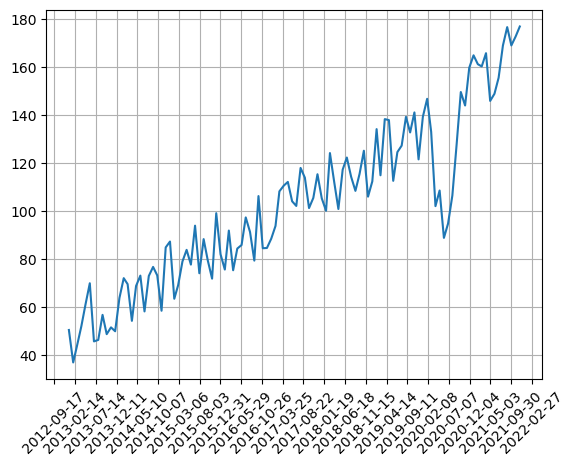

In [ ]:
x = dfexp['Date'][:500]
y = dfexp['Exports'][:500]

tick_spacing = 150

fig, ax = plt.subplots(1,1)
ax.plot(x,y)
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax.grid(True)
plt.xticks(rotation=45)
plt.show()

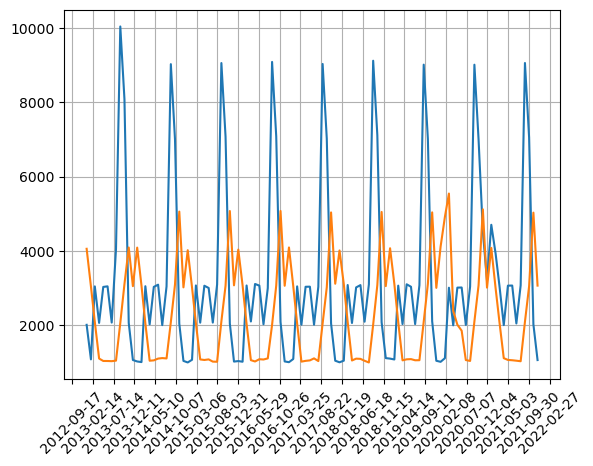

In [ ]:
x = dfpop['Date']
y1_born = dfpop['Births']
y2_dead = dfpop['Deaths']
y3_pop = dfpop['Population']


tick_spacing = 150

fig, ax = plt.subplots(1,1)
ax.plot(x,y1_born)
ax.plot(x,y2_dead)
#ax.plot(x,y3_pop) #high num
ax.xaxis.set_major_locator(ticker.MultipleLocator(tick_spacing))
ax.grid(True)
plt.xticks(rotation=45)
plt.show()

### Finding params (EXPORTS)

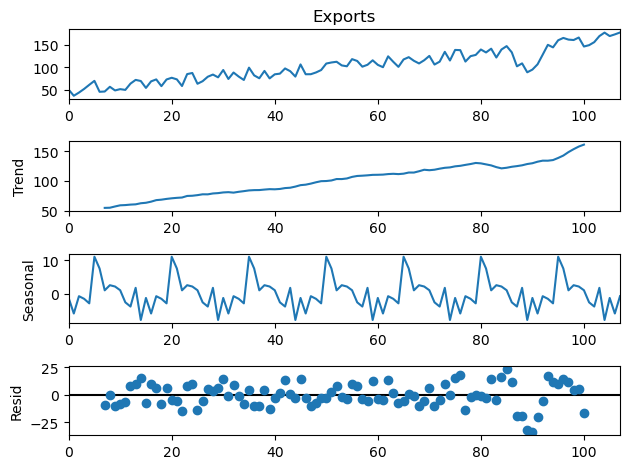

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(dfexp['Exports'], model='additive', period=15)
decomposition.plot()
plt.show()

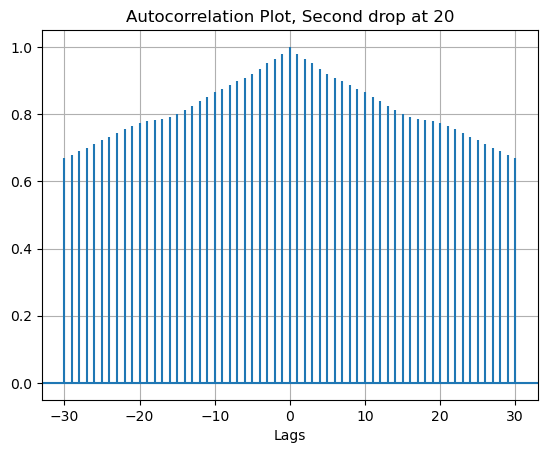

In [ ]:
expdata = np.array(dfexp['Exports'])

# Adding plot title.
plt.title("Autocorrelation Plot, Second drop at 20")

# Providing x-axis name.
plt.xlabel("Lags")

# Plotting the Autocorrelation plot.
plt.acorr(expdata, maxlags = 30)

plt.grid(True)

plt.show()

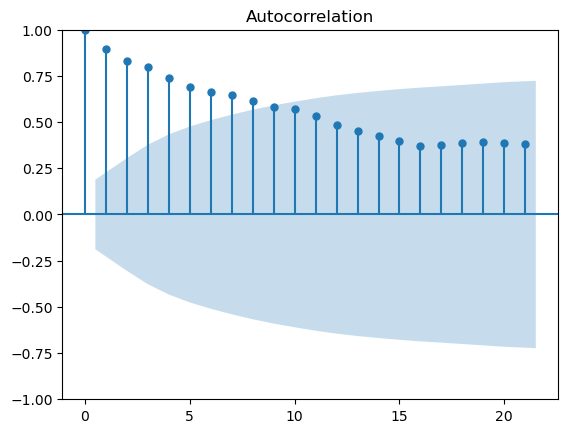

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(expdata);
#smooth

C:\Users\Anton\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


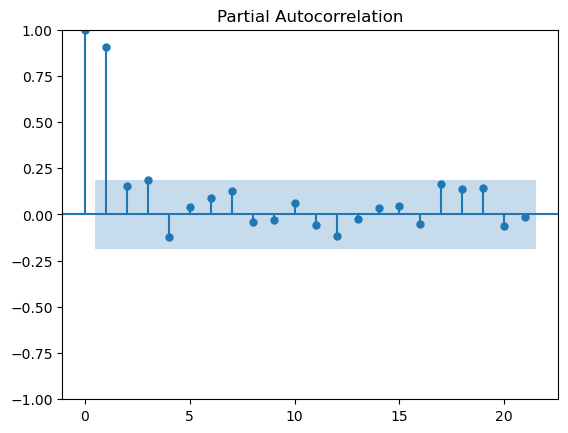

In [ ]:
plot_pacf(expdata);
#drop at 2

In [ ]:
from sklearn import metrics
prevError = 0

for shiftwindow in range(100):
    dfexp['T'] = dfexp['Exports']
    dfexp['T_t-1'] = dfexp['T'].shift(shiftwindow)
    dfexp_naive = dfexp[['T','T_t-1']][shiftwindow:]

    trueData = dfexp_naive['T']
    predictionData = dfexp_naive['T_t-1']

    error = sqrt(metrics.mean_squared_error(trueData,predictionData))
    print('RMSE for Naive Method with is: ', error, "---- ", shiftwindow)

    if error < prevError:
        print("!!smaller!!")

    prevError = error


RMSE for Naive Method with is:  0.0 ----  0
RMSE for Naive Method with is:  12.99050280385766 ----  1
RMSE for Naive Method with is:  15.498644374641996 ----  2
RMSE for Naive Method with is:  15.744732327115878 ----  3
RMSE for Naive Method with is:  18.145459061759162 ----  4
RMSE for Naive Method with is:  19.78004354584293 ----  5
RMSE for Naive Method with is:  20.49264271878154 ----  6
RMSE for Naive Method with is:  20.415626581537353 ----  7
!!smaller!!
RMSE for Naive Method with is:  21.27964388677507 ----  8
RMSE for Naive Method with is:  21.829620477031973 ----  9
RMSE for Naive Method with is:  21.397968792861434 ----  10
!!smaller!!
RMSE for Naive Method with is:  22.16332293319464 ----  11
RMSE for Naive Method with is:  23.63432904634924 ----  12
RMSE for Naive Method with is:  24.568799002946065 ----  13
RMSE for Naive Method with is:  25.556240836637247 ----  14
RMSE for Naive Method with is:  26.404761674257944 ----  15
RMSE for Naive Method with is:  27.422082824741

Error basically always rises so no clear seasonality here

Base-
P 0.8430798188033879 <-- This should be less than 0.05 for Stationary process.
Critial Values:
   1%, -3.4942202045135513
Critial Values:
   5%, -2.889485291005291
Critial Values:
   10%, -2.5816762131519275
CV -0.7140379079320419 <-- This value should be less than the CRITICAL VALUES listed above for Stationary.


1Diff-
P 7.492104683548307e-21 <-- This should be less than 0.05 for Stationary process.
Critial Values:
   1%, -3.4942202045135513
Critial Values:
   5%, -2.889485291005291
Critial Values:
   10%, -2.5816762131519275
CV -11.404874478442395 <-- This value should be less than the CRITICAL VALUES listed above for Stationary.


2Diff-
P 5.171390720498135e-08 <-- This should be less than 0.05 for Stationary process.
Critial Values:
   1%, -3.5019123847798657
Critial Values:
   5%, -2.892815255482889
Critial Values:
   10%, -2.583453861475781
CV -6.222899878476458 <-- This value should be less than the CRITICAL VALUES listed above for Stationary.


3Diff-
P 1.15921522580182

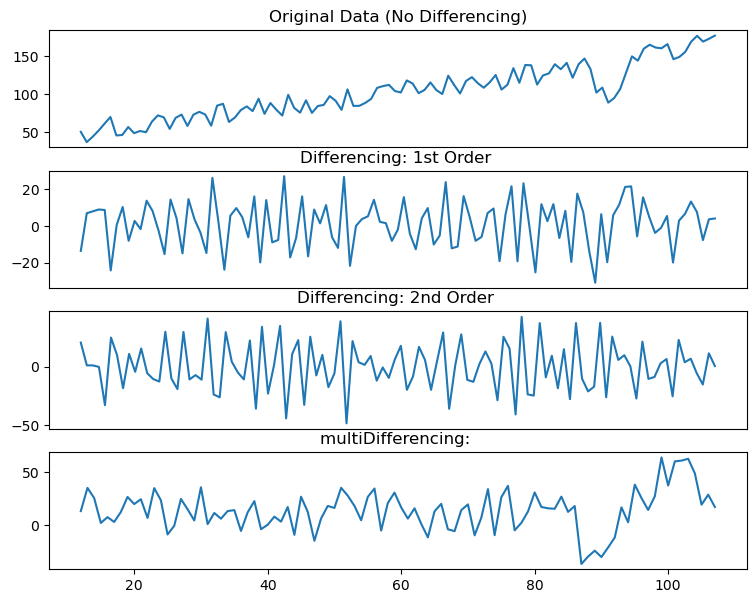

In [ ]:
from statsmodels.tsa.stattools import adfuller

plt.rcParams.update({'figure.figsize':(9,7)})

# The original Data
fig, (axisA, axisB, axisC, axisD) = plt.subplots(4)

axisA.plot(dfexp['Exports'])
axisA.set_title('Original Data (No Differencing)')
axisA.axes.xaxis.set_visible(False)

# After one Differencing
axisB.plot(dfexp['Exports'].diff());
axisB.set_title('Differencing: 1st Order ')
axisB.axes.xaxis.set_visible(False)

# After second Differencing
axisC.plot(dfexp['Exports'].diff().diff())
axisC.set_title('Differencing: 2nd Order ')
axisC.axes.xaxis.set_visible(False)

# After third Differencing
axisD.plot(dfexp['Exports'].diff(12));
axisD.set_title('multiDifferencing: ')
#axisD.axes.xaxis.set_visible(False)


print("Base-")
isStationary(dfexp["Exports"])
print("1Diff-")
isStationary(dfexp["Exports"].diff().dropna())
print("2Diff-")
isStationary(dfexp["Exports"].diff().diff().dropna())
print("3Diff-")
isStationary(dfexp["Exports"].diff().diff().diff().dropna())

print("12Diff-")
isStationary(dfexp["Exports"].diff(12).dropna())
print("1212Diff-")
isStationary(dfexp["Exports"].diff(12).diff(12).dropna())
print("121212Diff-")
isStationary(dfexp["Exports"].diff(12).diff(12).diff(12).dropna())

#1st order

In [ ]:
#No seasonality
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima

model_autoARIMA = auto_arima(dfexp['Exports'],stepwise=True,trace=True,error_action='ignore',suppress_warnings=True)

params = model_autoARIMA.get_params()

print(model_autoARIMA.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=855.509, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=847.319, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=839.472, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=854.396, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.08 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=836.872, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=837.677, Time=0.04 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : AIC=838.862, Time=0.05 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=838.852, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=841.629, Time=0.01 sec

Best model:  ARIMA(0,1,2)(0,0,0)[0] intercept
Total fit time: 0.455 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  108
Model:         

In [ ]:
model = SARIMAX(dfexp['Exports'],
                order=params['order'],
                seasonal_order=params['seasonal_order']
               )
model_fit = model.fit(disp=False)

#pred = model_fit.get_prediction(start=pd.to_datetime('2022-01-01'), end=pd.to_datetime('2022-06-30'), dynamic=False)
#pred_conf = pred.conf_int()

forecast = model_fit.get_forecast(steps=30)
pred_conf = forecast.conf_int()

forecasted_values = forecast.predicted_mean
df_forecasted = forecasted_values.to_frame()

In [ ]:
df_forecasted

,predicted_mean
108,173.758285
109,172.783529
110,172.783529
111,172.783529
112,172.783529
113,172.783529
114,172.783529
115,172.783529
116,172.783529
117,172.783529


In [ ]:
from sklearn.linear_model import LinearRegression

# Prepare the data
X = dfexp.index.values.reshape(-1, 1)
y = dfexp['Exports']

# Fit the model
model = LinearRegression()
model.fit(X, y)

y_pred_lr = model.predict(X)

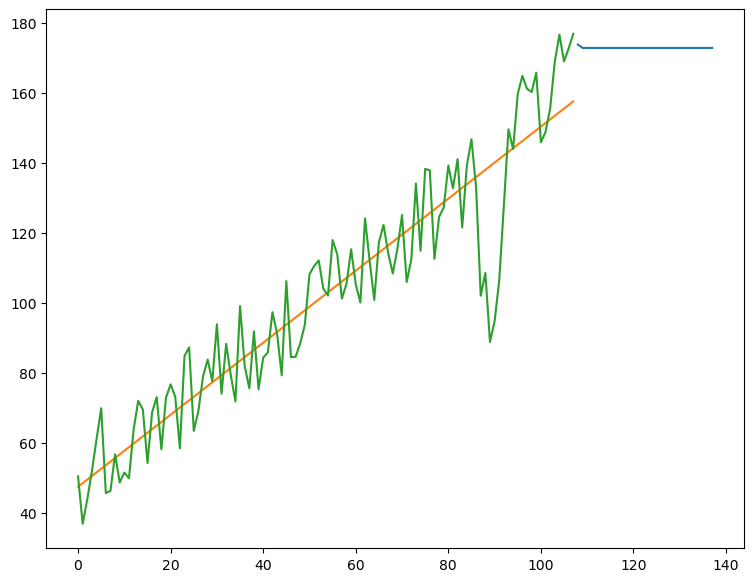

In [ ]:
plt.plot(df_forecasted['predicted_mean']) #no seasonality
plt.plot(y_pred_lr)
plt.plot(dfexp['Exports'])

### with seasonality

In [ ]:
model_autoARIMA = auto_arima(dfexp['Exports'], seasonal=True, m=15)
print(model_autoARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  108
Model:               SARIMAX(0, 1, 2)   Log Likelihood                -414.436
Date:                Wed, 15 May 2024   AIC                            836.872
Time:                        23:35:00   BIC                            847.564
Sample:                             0   HQIC                           841.206
                                - 108                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.1490      0.299      3.849      0.000       0.564       1.734
ma.L1         -0.4366      0.094     -4.653      0.000      -0.620      -0.253
ma.L2         -0.3255      0.090     -3.607      0.0

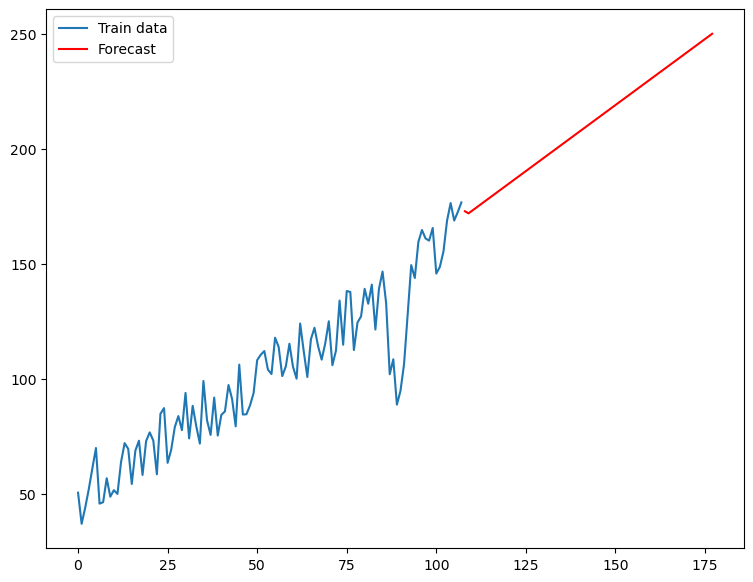

In [ ]:
plt.plot(dfexp["Exports"], label='Train data')
plt.plot(model_autoARIMA.predict(70), 'red', label='Forecast')
plt.legend()
plt.show()

In [ ]:
#m=20 seems to give the lowest AIC score, lower scores can be achieved by changing
#the order of seasonal differencing (100 ish) but the prediction looks terrible
model_autoARIMA = auto_arima(
dfexp["Exports"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3,
                         m=20, #12 is the frequncy of the cycle
                         start_P=1,
                         seasonal=True, #set to seasonal
                         d=None,
                         D=1, #order of the seasonal differencing
                         trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)
print(model_autoARIMA.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[20]             : AIC=inf, Time=1.43 sec
 ARIMA(0,1,0)(0,1,0)[20]             : AIC=755.362, Time=0.02 sec
 ARIMA(1,1,0)(1,1,0)[20]             : AIC=727.546, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[20]             : AIC=inf, Time=0.51 sec
 ARIMA(1,1,0)(0,1,0)[20]             : AIC=747.455, Time=0.04 sec
 ARIMA(1,1,0)(2,1,0)[20]             : AIC=728.935, Time=0.35 sec
 ARIMA(1,1,0)(1,1,1)[20]             : AIC=inf, Time=1.16 sec
 ARIMA(1,1,0)(0,1,1)[20]             : AIC=inf, Time=0.53 sec
 ARIMA(1,1,0)(2,1,1)[20]             : AIC=inf, Time=2.10 sec
 ARIMA(0,1,0)(1,1,0)[20]             : AIC=731.904, Time=0.09 sec
 ARIMA(2,1,0)(1,1,0)[20]             : AIC=716.589, Time=0.20 sec
 ARIMA(2,1,0)(0,1,0)[20]             : AIC=733.272, Time=0.07 sec
 ARIMA(2,1,0)(2,1,0)[20]             : AIC=718.239, Time=0.50 sec
 ARIMA(2,1,0)(1,1,1)[20]             : AIC=inf, Time=1.40 sec
 ARIMA(2,1,0)(0,1,1)[20]             : AIC=inf, Time=0.75

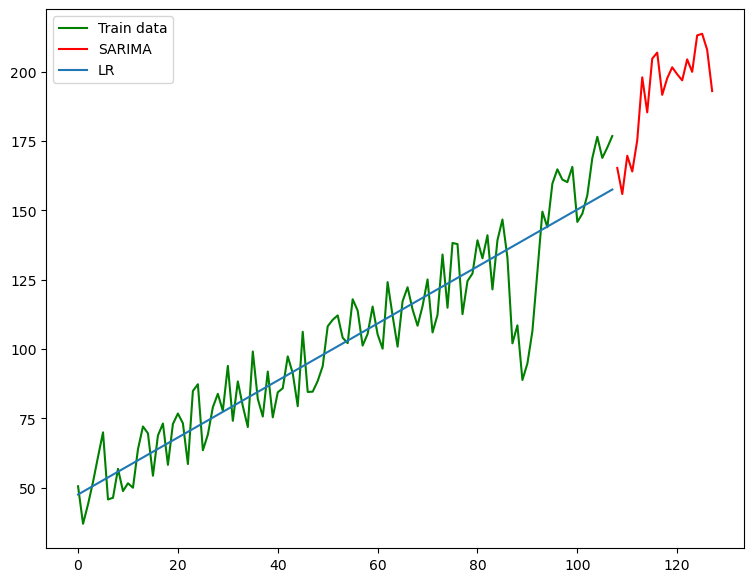

In [ ]:
plt.plot(dfexp["Exports"], 'green', label='Train data')

plt.plot(model_autoARIMA.predict(20), 'red', label='SARIMA')

plt.plot(y_pred_lr, label='LR')

plt.legend()
plt.show()

### Here it looks as if the Linear regression model would predict lower than the SARIMA model, the prediction is bad for the sarima model but the AIC value is lowest i could get it. The prediction looked better with

### Finding params (POPULATION)
I checked in excel with the moving average trendline trick and the line is at its straightest at 12 so thats the period im going with

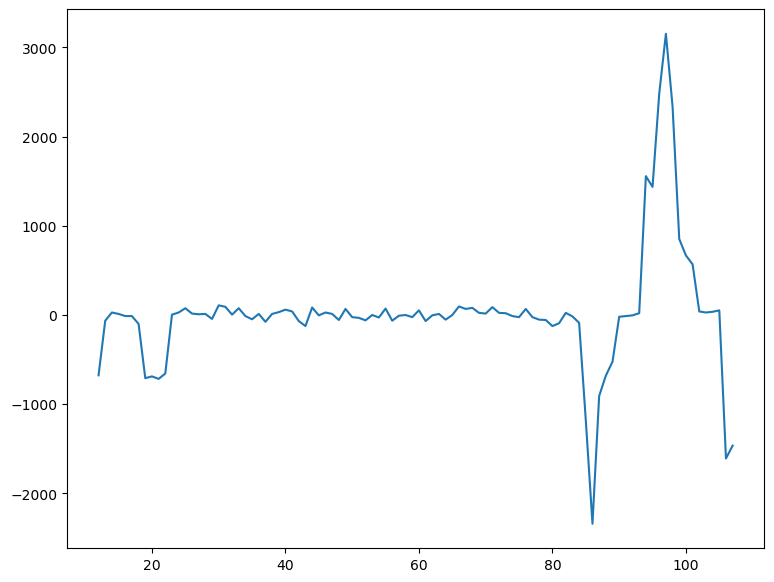

In [ ]:
plt.plot(dfpop['Population'].diff(12)) #gigaspike

<function matplotlib.pyplot.show(close=None, block=None)>

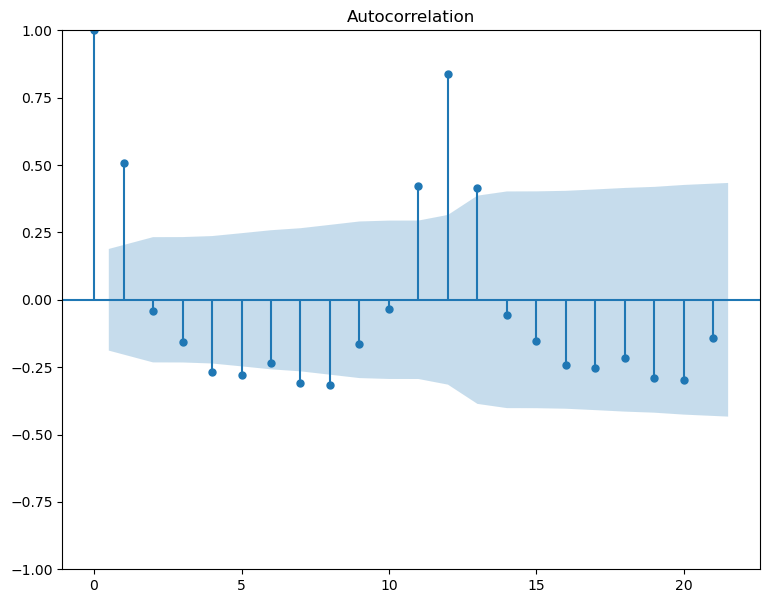

In [ ]:
popdata = np.array(dfpop['Population'])

plot_acf(popdata)
plt.show

In [ ]:
#Playing with D value seems to change the AIC score quite a bit
model_autoARIMA = auto_arima(
dfpop["Population"], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3,
                         m=12, #12 is the frequncy of the cycle
                         start_P=1,
                         seasonal=True, #set to seasonal
                         d=None,
                         D=1, #order of the seasonal differencing
                         trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)
print(model_autoARIMA.summary())

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[12]             : AIC=1424.285, Time=0.25 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1416.682, Time=0.01 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1418.515, Time=0.09 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1418.565, Time=0.13 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=1419.590, Time=0.06 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=1423.272, Time=0.06 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=1421.272, Time=0.16 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1416.532, Time=0.01 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=1418.515, Time=0.06 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=1420.522, Time=0.10 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1418.471, Time=0.02 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1420.293, Time=0.15 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=1416.580, Time=0.02 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1420.495, Time=0.03 sec
 ARIMA(1,1,0)(0,1,0

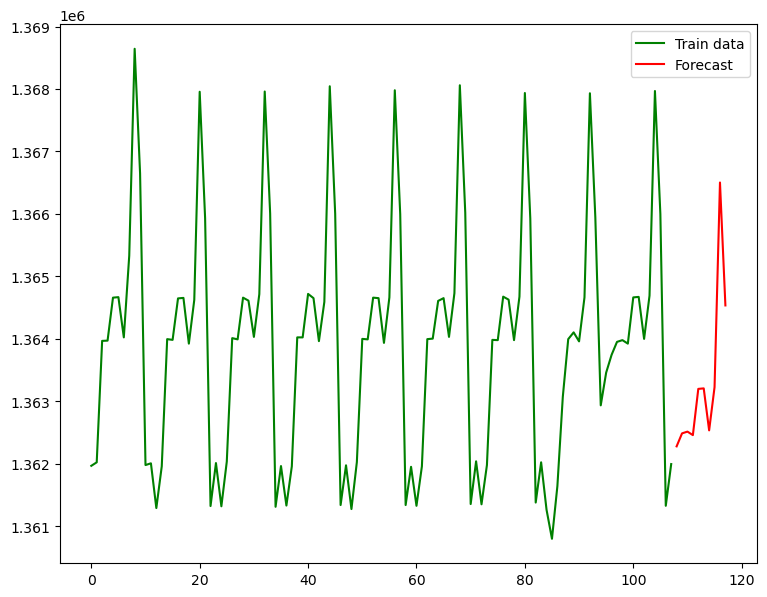

In [ ]:
#The spike/abnormality at the end is messing up the prediction I believe
plt.plot(dfpop["Population"], 'green', label='Train data')
plt.plot(model_autoARIMA.predict(start=0, end=180), 'red', label='Forecast')
plt.legend()
plt.show()

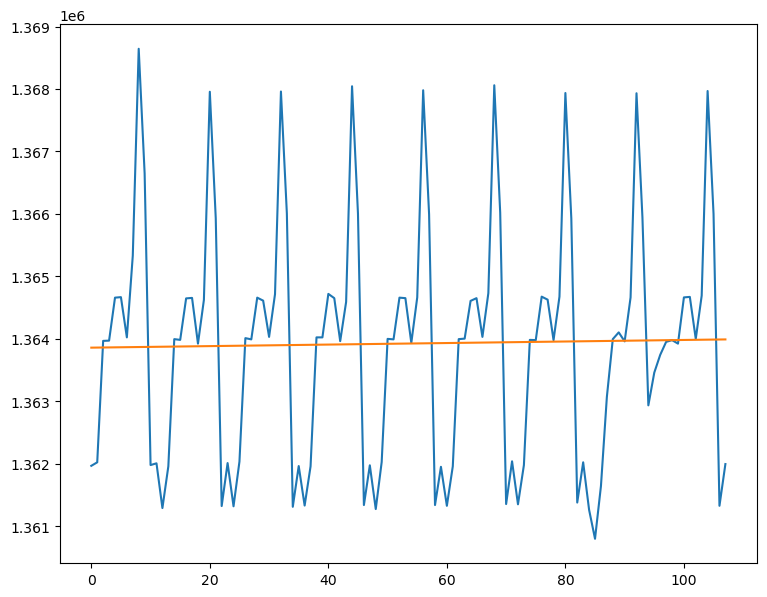

In [ ]:
# Prepare the data
X = dfpop.index.values.reshape(-1, 1)
y = dfpop['Population']

# Fit the model
model = LinearRegression()
model.fit(X, y)

y_pred_lr2 = model.predict(X)
plt.plot(dfpop["Population"])
plt.plot(y_pred_lr2)

I mean, im not sure what to get from this. Cant get the LR to actually follow the seasonality.